# LOB Data Exploration & Domain Shift Visualization

This notebook loads and visualizes Limit Order Book (LOB) data from two sources:
1. **LOBSTER (HuggingFace)** — Real NASDAQ US equity LOB data (AAPL, MSFT, etc.)
2. **FI-2010** — Finnish NASDAQ Nordic benchmark LOB data

We produce comparative plots to visualize **domain shifts** between datasets, assets, and markets.

## 1. Setup & Installation

In [1]:
!pip install -q datasets huggingface_hub matplotlib seaborn scipy numpy pandas

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.special import rel_entr
import warnings
warnings.filterwarnings('ignore')

# Plotting defaults
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})
sns.set_style('whitegrid')
print('Setup complete.')

Setup complete.


## 2. Load LOBSTER Data (HuggingFace)

The LOBSTER dataset on HuggingFace (`totalorganfailure/lobster-data`) contains orderbook and message files for several US stocks at various depth levels.

We load the raw CSV files directly from the HuggingFace repository since the auto-loader has column mismatch issues across subsets.

In [3]:
from huggingface_hub import hf_hub_download
import os

# ---- Configuration ----
REPO_ID = "totalorganfailure/lobster-data"

# We'll load 10-level orderbook data for AAPL and MSFT to compare two assets
# The files follow the pattern: LOBSTER_SampleFile_{TICKER}_{DATE}_10/{TICKER}_{DATE}_..._orderbook_10.csv
files_to_download = {
    "AAPL": {
        "orderbook": "LOBSTER_SampleFile_AAPL_2012-06-21_10/AAPL_2012-06-21_34200000_57600000_orderbook_10.csv",
        "message":   "LOBSTER_SampleFile_AAPL_2012-06-21_10/AAPL_2012-06-21_34200000_57600000_message_10.csv",
    },
    "MSFT": {
        "orderbook": "LOBSTER_SampleFile_MSFT_2012-06-21_10/MSFT_2012-06-21_34200000_57600000_orderbook_10.csv",
        "message":   "LOBSTER_SampleFile_MSFT_2012-06-21_10/MSFT_2012-06-21_34200000_57600000_message_10.csv",
    },
}

lobster_data = {}
for ticker, paths in files_to_download.items():
    lobster_data[ticker] = {}
    for ftype, fpath in paths.items():
        local_path = hf_hub_download(
            repo_id=REPO_ID,
            filename=fpath,
            repo_type="dataset"
        )
        lobster_data[ticker][ftype] = local_path
        print(f"Downloaded {ticker} {ftype}: {local_path}")

LOBSTER_SampleFile_AAPL_2012-06-21_10/AA(…):   0%|          | 0.00/93.5M [00:00<?, ?B/s]

Downloaded AAPL orderbook: /root/.cache/huggingface/hub/datasets--totalorganfailure--lobster-data/snapshots/fb51a829d2b5a78c79468db533ba28c5f1d161d0/LOBSTER_SampleFile_AAPL_2012-06-21_10/AAPL_2012-06-21_34200000_57600000_orderbook_10.csv


LOBSTER_SampleFile_AAPL_2012-06-21_10/AA(…):   0%|          | 0.00/16.6M [00:00<?, ?B/s]

Downloaded AAPL message: /root/.cache/huggingface/hub/datasets--totalorganfailure--lobster-data/snapshots/fb51a829d2b5a78c79468db533ba28c5f1d161d0/LOBSTER_SampleFile_AAPL_2012-06-21_10/AAPL_2012-06-21_34200000_57600000_message_10.csv


LOBSTER_SampleFile_MSFT_2012-06-21_10/MS(…):   0%|          | 0.00/170M [00:00<?, ?B/s]

Downloaded MSFT orderbook: /root/.cache/huggingface/hub/datasets--totalorganfailure--lobster-data/snapshots/fb51a829d2b5a78c79468db533ba28c5f1d161d0/LOBSTER_SampleFile_MSFT_2012-06-21_10/MSFT_2012-06-21_34200000_57600000_orderbook_10.csv


LOBSTER_SampleFile_MSFT_2012-06-21_10/MS(…):   0%|          | 0.00/27.6M [00:00<?, ?B/s]

Downloaded MSFT message: /root/.cache/huggingface/hub/datasets--totalorganfailure--lobster-data/snapshots/fb51a829d2b5a78c79468db533ba28c5f1d161d0/LOBSTER_SampleFile_MSFT_2012-06-21_10/MSFT_2012-06-21_34200000_57600000_message_10.csv


In [4]:
def load_lobster_orderbook(filepath, n_levels=10):
    """
    Load a LOBSTER orderbook CSV.

    LOBSTER orderbook format (no header): for each level i (1..n_levels):
      ask_price_i, ask_volume_i, bid_price_i, bid_volume_i
    Prices are in dollar-cents (integer, divide by 10000 to get dollars).
    """
    cols = []
    for i in range(1, n_levels + 1):
        cols += [f'ask_price_{i}', f'ask_vol_{i}', f'bid_price_{i}', f'bid_vol_{i}']

    df = pd.read_csv(filepath, header=None, names=cols)
    # Convert prices from integer (hundredths of cents) to dollars
    price_cols = [c for c in df.columns if 'price' in c]
    df[price_cols] = df[price_cols] / 10000.0
    return df


def load_lobster_message(filepath):
    """
    Load a LOBSTER message CSV.

    Columns: Time, EventType, OrderID, Size, Price, Direction
    Time is seconds after midnight.
    """
    cols = ['time', 'event_type', 'order_id', 'size', 'price', 'direction']
    df = pd.read_csv(filepath, header=None, names=cols)
    df['price'] = df['price'] / 10000.0
    return df


# Load orderbook and message data for each ticker
ob = {}   # orderbook DataFrames
msg = {}  # message DataFrames

for ticker in lobster_data:
    ob[ticker] = load_lobster_orderbook(lobster_data[ticker]['orderbook'])
    msg[ticker] = load_lobster_message(lobster_data[ticker]['message'])
    print(f"{ticker}: orderbook shape = {ob[ticker].shape}, messages shape = {msg[ticker].shape}")

AAPL: orderbook shape = (400391, 40), messages shape = (400391, 6)
MSFT: orderbook shape = (668765, 40), messages shape = (668765, 6)


In [5]:
def compute_lob_features(ob_df, msg_df):
    """
    Compute standard LOB features from orderbook and message DataFrames.
    Returns a DataFrame with: mid_price, spread, return, order_imbalance, etc.
    """
    features = pd.DataFrame()
    features['best_ask'] = ob_df['ask_price_1']
    features['best_bid'] = ob_df['bid_price_1']
    features['mid_price'] = (features['best_ask'] + features['best_bid']) / 2.0
    features['spread'] = features['best_ask'] - features['best_bid']
    features['mid_return'] = features['mid_price'].pct_change()

    # Order imbalance (level 1)
    features['bid_vol_1'] = ob_df['bid_vol_1']
    features['ask_vol_1'] = ob_df['ask_vol_1']
    features['order_imbalance'] = (
        (features['bid_vol_1'] - features['ask_vol_1']) /
        (features['bid_vol_1'] + features['ask_vol_1'])
    )

    # Total depth (sum of volumes across all levels)
    bid_vol_cols = [c for c in ob_df.columns if c.startswith('bid_vol')]
    ask_vol_cols = [c for c in ob_df.columns if c.startswith('ask_vol')]
    features['total_bid_depth'] = ob_df[bid_vol_cols].sum(axis=1)
    features['total_ask_depth'] = ob_df[ask_vol_cols].sum(axis=1)

    # Time (from message file)
    if msg_df is not None and len(msg_df) == len(ob_df):
        features['time'] = msg_df['time']
        features['inter_arrival'] = features['time'].diff()

    def compute_labels(mid_price, h, eps=1e-5):
        future_price = mid_price.shift(-h)
        diff = future_price - mid_price

        labels = np.where(
            diff > eps, 3,
            np.where(diff < -eps, 1, 2)
        )
        return labels

    features['label_h10'] = compute_labels(features['mid_price'], 10)
    features['label_h20'] = compute_labels(features['mid_price'], 20)
    features['label_h50'] = compute_labels(features['mid_price'], 50)

    features = features.dropna().reset_index(drop=True)
    return features


# Compute features for each ticker
feat = {}
for ticker in ob:
    feat[ticker] = compute_lob_features(ob[ticker], msg[ticker])
    print(f"{ticker} features: {feat[ticker].shape[0]} rows")
    display(feat[ticker].describe().round(6))

AAPL features: 400390 rows


,best_ask,best_bid,mid_price,spread,mid_return,bid_vol_1,ask_vol_1,order_imbalance,total_bid_depth,total_ask_depth,time,inter_arrival,label_h10,label_h20,label_h50
count,400390.000000,400390.000000,400390.000000,400390.000000,400390.000000,400390.000000,400390.000000,400390.000000,400390.000000,400390.000000,400390.000000,400390.000000,400390.000000,400390.000000,400390.000000
mean,583.229587,583.076099,583.152843,0.153488,-0.000000,184.085856,140.123472,0.069744,1828.901721,1496.552911,46281.398303,0.058443,1.990617,1.977719,1.963471
std,2.850828,2.819535,2.834983,0.074154,0.000018,532.130959,288.579579,0.569702,1519.247703,1017.586551,7490.003021,0.208833,0.798476,0.894404,0.961650
min,577.500000,577.450000,577.480000,0.010000,-0.000511,1.000000,1.000000,-0.999375,165.000000,96.000000,34200.004261,0.000000,1.000000,1.000000,1.000000
25%,581.300000,581.180000,581.245000,0.100000,0.000000,94.000000,33.000000,-0.333333,1018.000000,890.000000,39551.399788,0.000073,1.000000,1.000000,1.000000
50%,583.310000,583.170000,583.235000,0.150000,0.000000,100.000000,100.000000,0.000000,1372.000000,1178.000000,45969.709196,0.000639,2.000000,2.000000,2.000000
75%,585.770000,585.560000,585.660000,0.200000,0.000000,200.000000,140.000000,0.587302,2120.000000,1772.000000,53517.591794,0.009320,3.000000,3.000000,3.000000
max,588.220000,588.150000,588.185000,0.920000,0.000452,22244.000000,15041.000000,0.999513,24629.000000,15962.000000,57599.913118,8.155205,3.000000,3.000000,3.000000


MSFT features: 668764 rows


,best_ask,best_bid,mid_price,spread,mid_return,bid_vol_1,ask_vol_1,order_imbalance,total_bid_depth,total_ask_depth,time,inter_arrival,label_h10,label_h20,label_h50
count,668764.000000,668764.000000,668764.000000,668764.000000,668764.000000,668764.000000,668764.000000,668764.000000,668764.000000,668764.000000,668764.000000,668764.000000,668764.000000,668764.000000,668764.000000
mean,30.555105,30.542785,30.548945,0.012320,-0.000000,14129.000514,14957.434841,-0.028776,146513.506056,147283.064700,45874.266018,0.034990,1.997193,1.994155,1.985195
std,0.286348,0.286016,0.286174,0.004239,0.000013,11316.204021,11316.313932,0.413945,48079.404670,45145.791214,7537.137245,0.148480,0.232696,0.319281,0.470605
min,30.070000,30.060000,30.065000,0.010000,-0.000323,1.000000,1.000000,-0.999882,5786.000000,4988.000000,34200.013994,0.000000,1.000000,1.000000,1.000000
25%,30.310000,30.300000,30.305000,0.010000,0.000000,7766.000000,8622.000000,-0.320571,128654.000000,127916.000000,39180.213692,0.000005,2.000000,2.000000,2.000000
50%,30.520000,30.500000,30.510000,0.010000,0.000000,12030.000000,13115.000000,-0.048241,147133.000000,149929.000000,45161.661480,0.000051,2.000000,2.000000,2.000000
75%,30.820000,30.810000,30.815000,0.010000,0.000000,17522.000000,18408.000000,0.257169,166003.000000,168542.000000,53382.844810,0.000970,2.000000,2.000000,2.000000
max,31.150000,31.130000,31.140000,0.050000,0.000646,128500.000000,216430.000000,0.999805,500356.000000,602930.000000,57599.907797,5.798992,3.000000,3.000000,3.000000


## 3. Load FI-2010 Data

The FI-2010 benchmark is available from the DeepLOB GitHub repository.
It's stored as a `.npy` file with shape `(149, ~400k)`: 40 LOB features + 109 handcrafted features + labels.
We use the first 40 rows (10 levels × 4: ask_price, ask_vol, bid_price, bid_vol).

In [6]:
# Download FI-2010 data from the DeepLOB repo
!wget -q -O data.zip https://raw.githubusercontent.com/zcakhaa/DeepLOB-Deep-Convolutional-Neural-Networks-for-Limit-Order-Books/master/data/data.zip
!unzip -qo data.zip -d fi2010_data
!ls fi2010_data/

Test_Dst_NoAuction_DecPre_CF_7.txt  Test_Dst_NoAuction_DecPre_CF_9.txt
Test_Dst_NoAuction_DecPre_CF_8.txt  Train_Dst_NoAuction_DecPre_CF_7.txt


In [7]:
# The FI-2010 .npy files are typically found under a path like:
# fi2010_data/data/data/BenchmarkDatasets/...
# Let's find the actual .npy files
import glob

npy_files = glob.glob('fi2010_data/**/*.npy', recursive=True)
txt_files = glob.glob('fi2010_data/**/*.txt', recursive=True)
all_data_files = glob.glob('fi2010_data/**/*', recursive=True)

print(f"Found {len(npy_files)} .npy files")
print(f"Found {len(txt_files)} .txt files")
print(f"Total files: {len(all_data_files)}")
for f in all_data_files[:20]:
    print(f"  {f}")

Found 0 .npy files
Found 4 .txt files
Total files: 4
  fi2010_data/Test_Dst_NoAuction_DecPre_CF_7.txt
  fi2010_data/Test_Dst_NoAuction_DecPre_CF_9.txt
  fi2010_data/Train_Dst_NoAuction_DecPre_CF_7.txt
  fi2010_data/Test_Dst_NoAuction_DecPre_CF_8.txt


In [8]:
# Load the FI-2010 data
# The DeepLOB repo stores it as Train_Dst_NoAuction_ZScore_CF_{i}.txt files (i = 1..9)
# and Test files. Each file has shape (149, T_i) where the first 40 rows are LOB features.
# Rows 0-39: LOB features (ask_price_1, ask_vol_1, bid_price_1, bid_vol_1, ... for 10 levels)
# Rows 40-143: handcrafted features
# Rows 144-148: labels for 5 prediction horizons

def load_fi2010(data_dir='fi2010_data'):
    """
    Load FI-2010 data. Searches for .txt files from the DeepLOB format.
    Returns the raw LOB features (first 40 rows) as a DataFrame.
    """
    # Try to find the training data files
    patterns = [
        f'{data_dir}/**/Train_Dst_NoAuction_ZScore_CF_*.txt',
        f'{data_dir}/**/NoAuction_Zscore_Training/Train_Dst_NoAuction_ZScore_CF_*.txt',
        f'{data_dir}/**/*Train*.txt',
        f'{data_dir}/**/*.txt',
    ]

    train_files = []
    for pattern in patterns:
        train_files = sorted(glob.glob(pattern, recursive=True))
        if train_files:
            break

    if not train_files:
        # Try .npy format
        npy_files = sorted(glob.glob(f'{data_dir}/**/*.npy', recursive=True))
        if npy_files:
            data = np.load(npy_files[0])
            print(f"Loaded .npy file: {npy_files[0]}, shape: {data.shape}")
            return data
        print("No FI-2010 data files found!")
        return None

    print(f"Found {len(train_files)} training files")
    all_data = []
    for f in train_files:
        d = np.loadtxt(f)
        all_data.append(d)
        print(f"  Loaded {f}: shape {d.shape}")

    # Concatenate along time axis (axis=1)
    data = np.hstack(all_data)
    print(f"Combined FI-2010 data shape: {data.shape}")
    return data


fi2010_raw = load_fi2010()

Found 1 training files
  Loaded fi2010_data/Train_Dst_NoAuction_DecPre_CF_7.txt: shape (149, 254750)
Combined FI-2010 data shape: (149, 254750)


In [9]:
def fi2010_to_features(data):
    """
    Extract LOB features from the FI-2010 matrix.
    First 40 rows = LOB data: for each level i (1..10):
      row 4*(i-1)+0 = ask_price_i
      row 4*(i-1)+1 = ask_vol_i
      row 4*(i-1)+2 = bid_price_i
      row 4*(i-1)+3 = bid_vol_i
    Note: FI-2010 is z-score normalized, so values are standardized.
    """
    if data is None:
        return None

    lob = data[:40, :]  # 40 x T
    features = pd.DataFrame()
    features['ask_price_1'] = lob[0, :]
    features['ask_vol_1'] = lob[1, :]
    features['bid_price_1'] = lob[2, :]
    features['bid_vol_1'] = lob[3, :]
    features['mid_price'] = (features['ask_price_1'] + features['bid_price_1']) / 2.0
    features['spread'] = features['ask_price_1'] - features['bid_price_1']
    features['mid_return'] = features['mid_price'].diff()
    features['order_imbalance'] = (
        (features['bid_vol_1'] - features['ask_vol_1']) /
        (features['bid_vol_1'] + features['ask_vol_1']).replace(0, np.nan)
    )

    # Total depth across 10 levels
    bid_vols = lob[[4*i + 3 for i in range(10)], :]
    ask_vols = lob[[4*i + 1 for i in range(10)], :]
    features['total_bid_depth'] = bid_vols.sum(axis=0)
    features['total_ask_depth'] = ask_vols.sum(axis=0)

    # Labels (rows 144-148: horizons 10, 20, 30, 50, 100)
    if data.shape[0] > 144:
        features['label_h10'] = data[144, :]
        features['label_h50'] = data[147, :]

    features = features.dropna().reset_index(drop=True)
    return features


fi2010_feat = fi2010_to_features(fi2010_raw)
if fi2010_feat is not None:
    print(f"FI-2010 features: {fi2010_feat.shape[0]} rows")
    display(fi2010_feat.describe().round(6))

FI-2010 features: 254749 rows


,ask_price_1,ask_vol_1,bid_price_1,bid_vol_1,mid_price,spread,mid_return,order_imbalance,total_bid_depth,total_ask_depth,label_h10,label_h50
count,254749.000000,254749.000000,254749.000000,254749.000000,254749.000000,254749.000000,254749.000000,254749.000000,254749.000000,254749.000000,254749.000000,254749.000000
mean,0.228295,0.011254,0.227911,0.011904,0.228103,0.000384,0.000000,-0.004723,0.199624,0.194737,2.000075,1.995549
std,0.100093,0.013581,0.099920,0.016289,0.100007,0.000269,0.000531,0.532187,0.155536,0.148510,0.628233,0.826624
min,0.120300,0.000010,0.120200,0.000010,0.120250,0.000100,-0.139000,-0.999793,0.008430,0.007970,1.000000,1.000000
25%,0.127200,0.002500,0.127000,0.002230,0.127100,0.000200,0.000000,-0.448276,0.052050,0.056950,2.000000,1.000000
50%,0.174000,0.006000,0.173800,0.005720,0.173950,0.000300,0.000000,0.000000,0.200470,0.187840,2.000000,2.000000
75%,0.345300,0.014930,0.344600,0.015680,0.344950,0.000500,0.000000,0.432714,0.317040,0.299540,2.000000,3.000000
max,0.366800,0.244990,0.365900,0.600010,0.366350,0.005100,0.217650,0.999690,0.912020,0.857400,3.000000,3.000000


## 4. Domain Shift Visualizations

In [10]:
### 4.1 Cross-Asset Comparison (AAPL vs MSFT — LOBSTER)

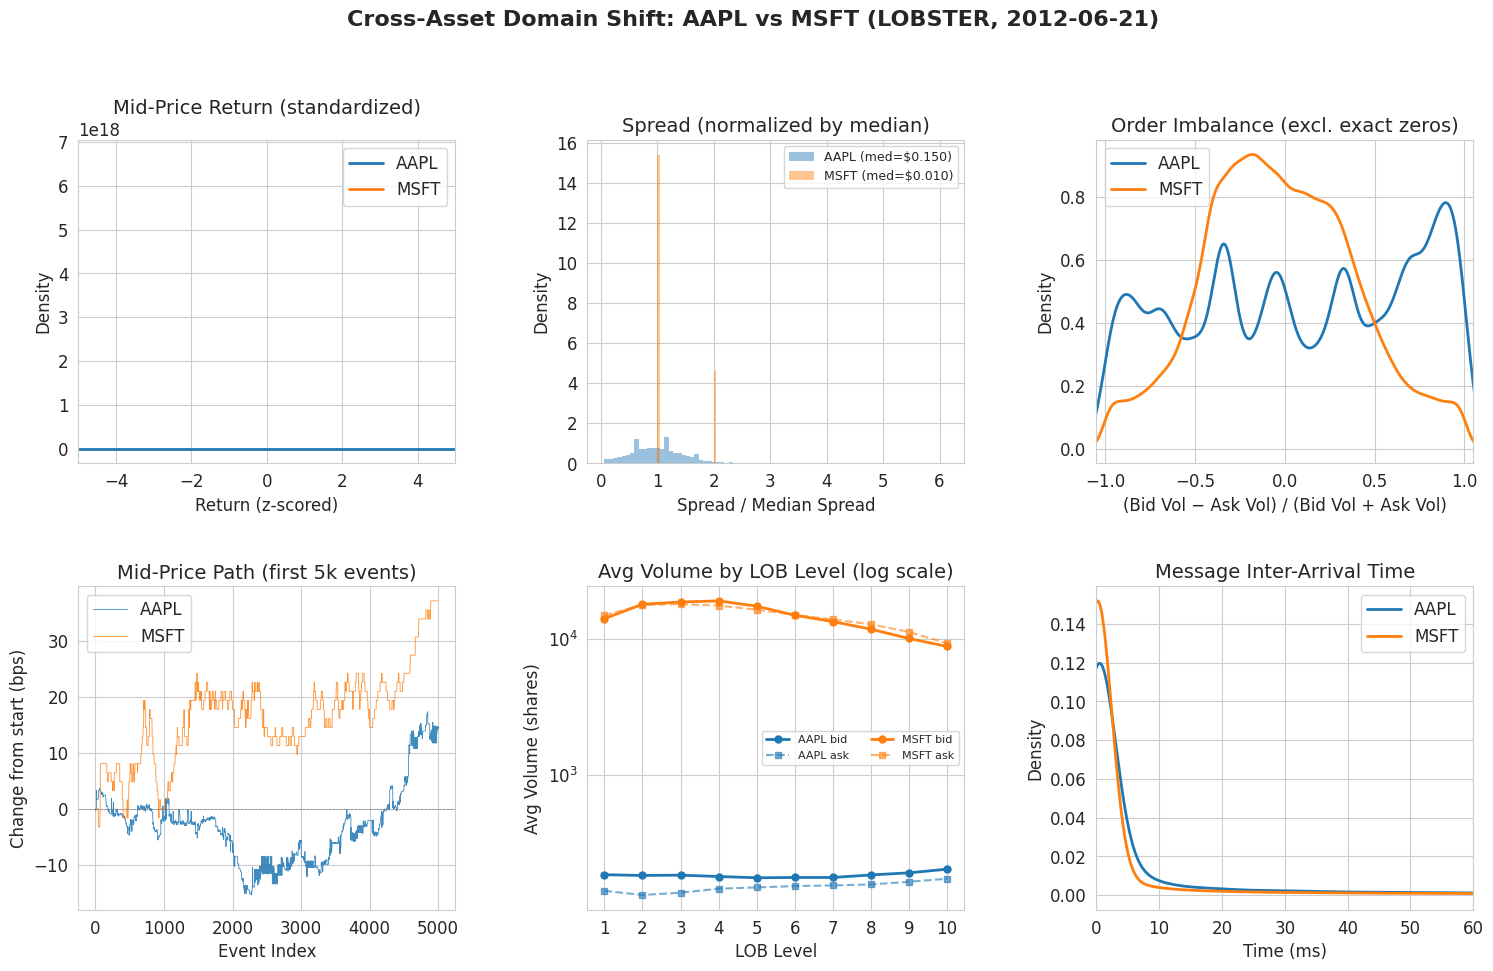

Saved: cross_asset_domain_shift.png


In [11]:
fig = plt.figure(figsize=(18, 10))
fig.suptitle('Cross-Asset Domain Shift: AAPL vs MSFT (LOBSTER, 2012-06-21)',
             fontsize=16, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(2, 3, hspace=0.38, wspace=0.35)
colors = {'AAPL': '#1f77b4', 'MSFT': '#ff7f0e'}

# ──────────────────────────────────────────────────────
# (0,0) Mid-price return — KDE, each standardized to z-score
# ──────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
for ticker in ['AAPL', 'MSFT']:
    r = feat[ticker]['mid_return'].dropna()
    r_z = (r - r.mean()) / r.std()
    r_z = r_z[(r_z > -5) & (r_z < 5)]
    r_z.plot.kde(ax=ax, label=ticker, color=colors[ticker], linewidth=2)
ax.set_title('Mid-Price Return (standardized)')
ax.set_xlabel('Return (z-scored)')
ax.set_ylabel('Density')
ax.set_xlim(-5, 5)
ax.legend()

# ──────────────────────────────────────────────────────
# (0,1) Spread — normalized by each stock's median spread
# ──────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
for ticker in ['AAPL', 'MSFT']:
    sp = feat[ticker]['spread']
    sp_norm = sp / sp.median()
    sp_norm = sp_norm[sp_norm < 10]
    ax.hist(sp_norm, bins=80, alpha=0.45, density=True,
            label=f"{ticker} (med=${sp.median():.3f})",
            color=colors[ticker], edgecolor='none')
ax.set_title('Spread (normalized by median)')
ax.set_xlabel('Spread / Median Spread')
ax.set_ylabel('Density')
ax.legend(fontsize=9)

# ──────────────────────────────────────────────────────
# (0,2) Order imbalance — KDE, exclude exact-zero spike
# ──────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
for ticker in ['AAPL', 'MSFT']:
    oi = feat[ticker]['order_imbalance'].dropna()
    oi_nz = oi[oi != 0.0]
    oi_nz.plot.kde(ax=ax, label=ticker, color=colors[ticker],
                    linewidth=2, bw_method=0.1)
ax.set_title('Order Imbalance (excl. exact zeros)')
ax.set_xlabel('(Bid Vol \u2212 Ask Vol) / (Bid Vol + Ask Vol)')
ax.set_ylabel('Density')
ax.set_xlim(-1.05, 1.05)
ax.legend()

# ──────────────────────────────────────────────────────
# (1,0) Mid-price path in basis points from start
# ──────────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
n_show = 5000
for ticker in ['AAPL', 'MSFT']:
    mp = feat[ticker]['mid_price'].values[:n_show]
    bps = (mp / mp[0] - 1) * 10000
    ax.plot(bps, alpha=0.85, label=ticker, color=colors[ticker], linewidth=0.6)
ax.set_title('Mid-Price Path (first 5k events)')
ax.set_xlabel('Event Index')
ax.set_ylabel('Change from start (bps)')
ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.legend()

# ──────────────────────────────────────────────────────
# (1,1) Avg volume profile by LOB level — LOG scale
# ──────────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
levels = np.arange(1, 11)
for ticker in ['AAPL', 'MSFT']:
    bid_prof = [ob[ticker][f'bid_vol_{i}'].mean() for i in range(1, 11)]
    ask_prof = [ob[ticker][f'ask_vol_{i}'].mean() for i in range(1, 11)]
    ax.plot(levels, bid_prof, 'o-', label=f'{ticker} bid', color=colors[ticker],
            linewidth=2, markersize=5)
    ax.plot(levels, ask_prof, 's--', label=f'{ticker} ask', color=colors[ticker],
            linewidth=1.5, markersize=4, alpha=0.6)
ax.set_yscale('log')
ax.set_title('Avg Volume by LOB Level (log scale)')
ax.set_xlabel('LOB Level')
ax.set_ylabel('Avg Volume (shares)')
ax.set_xticks(levels)
ax.legend(fontsize=8, ncol=2)

# ──────────────────────────────────────────────────────
# (1,2) Inter-arrival time — KDE
# ──────────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 2])
for ticker in ['AAPL', 'MSFT']:
    ia = feat[ticker]['inter_arrival'].dropna()
    ia_ms = ia[ia > 0] * 1000
    ia_ms = ia_ms[ia_ms < 100]
    ia_ms.plot.kde(ax=ax, label=ticker, color=colors[ticker],
                    linewidth=2, bw_method=0.15)
ax.set_title('Message Inter-Arrival Time')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Density')
ax.set_xlim(0, 60)
ax.legend()

plt.savefig('cross_asset_domain_shift.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cross_asset_domain_shift.png')

### 4.2 Cross-Market Comparison (FI-2010 vs LOBSTER)

Note: FI-2010 is z-score normalized, so distributions will differ in scale from the raw LOBSTER data. We compare *structural* properties: spread shape, imbalance, and return tail behavior.

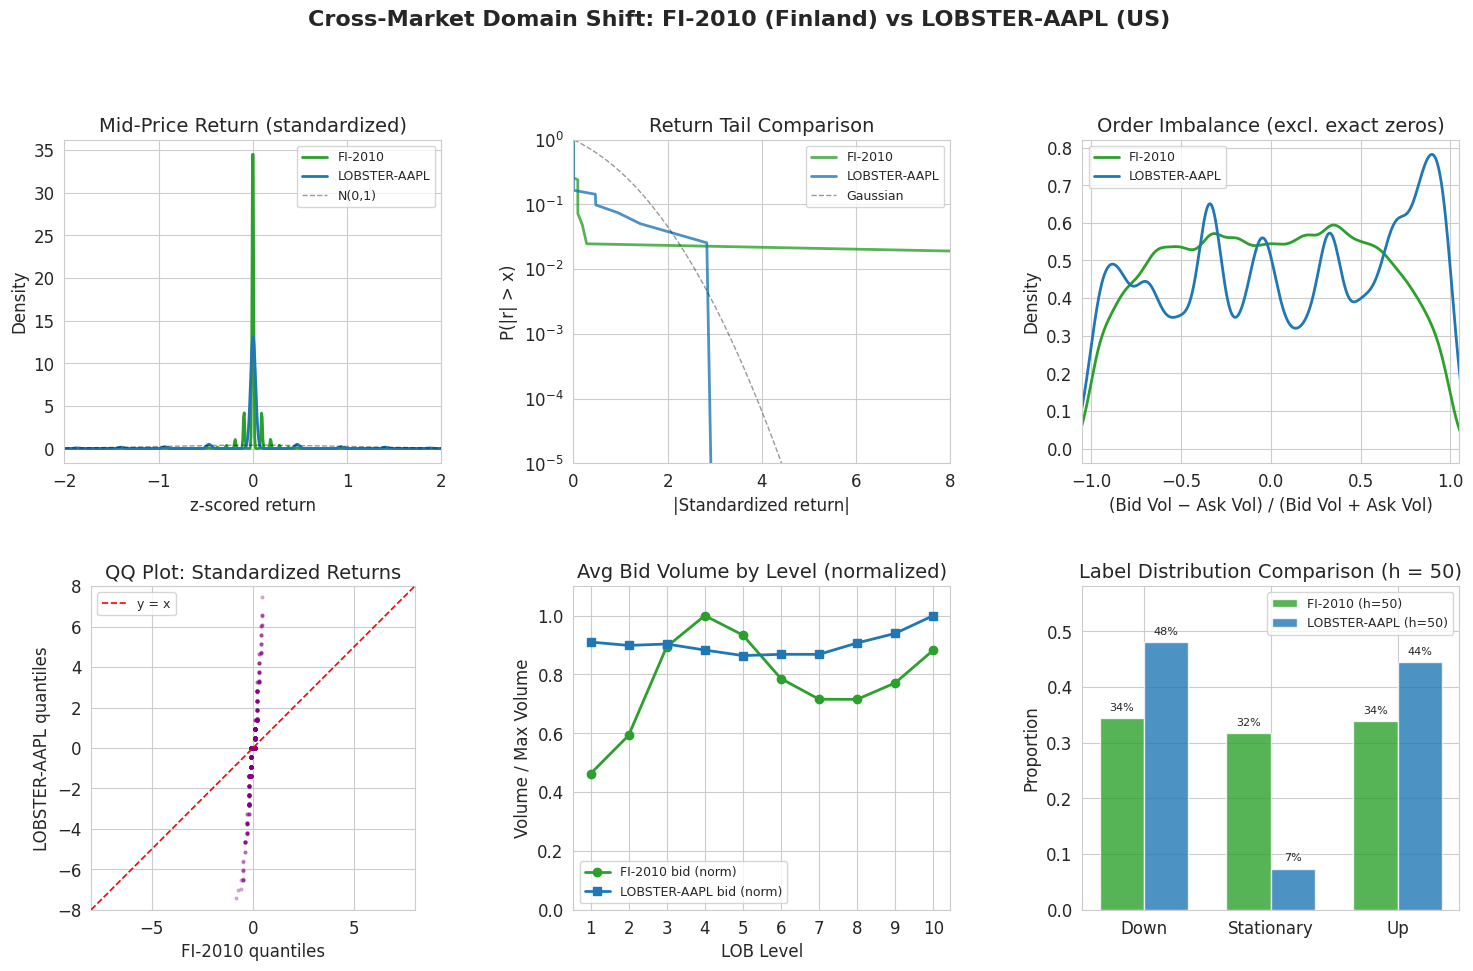

Saved: cross_market_domain_shift.png


In [13]:
if fi2010_feat is not None:
    fig = plt.figure(figsize=(18, 10))
    fig.suptitle('Cross-Market Domain Shift: FI-2010 (Finland) vs LOBSTER-AAPL (US)',
                 fontsize=16, fontweight='bold', y=1.01)

    gs = gridspec.GridSpec(2, 3, hspace=0.38, wspace=0.35)
    c_fi = '#2ca02c'
    c_lo = '#1f77b4'

    # ---- Prepare standardized returns ----
    # FI-2010: diff() of z-scored mid-prices, then standardize
    fi_ret_raw = fi2010_feat['mid_return'].dropna()
    fi_ret_z = (fi_ret_raw - fi_ret_raw.mean()) / fi_ret_raw.std()

    # LOBSTER: pct_change() returns, then standardize
    lo_ret_raw = feat['AAPL']['mid_return'].dropna()
    lo_ret_z = (lo_ret_raw - lo_ret_raw.mean()) / lo_ret_raw.std()

    # ──────────────────────────────────────────────────────
    # (0,0) Return KDE — both standardized, now comparable
    # ──────────────────────────────────────────────────────
    ax = fig.add_subplot(gs[0, 0])
    fi_clip = fi_ret_z[(fi_ret_z > -2) & (fi_ret_z < 2)]
    lo_clip = lo_ret_z[(lo_ret_z > -2) & (lo_ret_z < 2)]
    fi_clip.plot.kde(ax=ax, label='FI-2010', color=c_fi, linewidth=2)
    lo_clip.plot.kde(ax=ax, label='LOBSTER-AAPL', color=c_lo, linewidth=2)
    # Gaussian reference
    x_ref = np.linspace(-2, 2, 300)
    ax.plot(x_ref, stats.norm.pdf(x_ref), 'k--', linewidth=1, alpha=0.4, label='N(0,1)')
    ax.set_title('Mid-Price Return (standardized)')
    ax.set_xlabel('z-scored return')
    ax.set_ylabel('Density')
    ax.set_xlim(-2, 2)
    ax.legend(fontsize=9)

    # ──────────────────────────────────────────────────────
    # (0,1) Return tail plot — log P(|r| > x) vs x
    # ──────────────────────────────────────────────────────
    ax = fig.add_subplot(gs[0, 1])
    for label, data_z, color in [('FI-2010', fi_ret_z, c_fi), ('LOBSTER-AAPL', lo_ret_z, c_lo)]:
        abs_r = np.sort(np.abs(data_z.values))
        ccdf = 1.0 - np.arange(1, len(abs_r) + 1) / len(abs_r)
        # Subsample for clean plotting
        idx = np.unique(np.logspace(0, np.log10(len(abs_r) - 1), 500).astype(int))
        ax.plot(abs_r[idx], ccdf[idx], '-', label=label, color=color,
                linewidth=2, alpha=0.8)
    x_g = np.linspace(0.01, 8, 200)
    ax.plot(x_g, 2 * (1 - stats.norm.cdf(x_g)), 'k--', linewidth=1,
            alpha=0.4, label='Gaussian')
    ax.set_yscale('log')
    ax.set_title('Return Tail Comparison')
    ax.set_xlabel('|Standardized return|')
    ax.set_ylabel('P(|r| > x)')
    ax.set_xlim(0, 8)
    ax.set_ylim(1e-5, 1)
    ax.legend(fontsize=9)

    # ──────────────────────────────────────────────────────
    # (0,2) Order imbalance — KDE, exclude zeros
    # ──────────────────────────────────────────────────────
    ax = fig.add_subplot(gs[0, 2])
    fi_oi = fi2010_feat['order_imbalance'].dropna()
    lo_oi = feat['AAPL']['order_imbalance'].dropna()
    fi_oi_nz = fi_oi[fi_oi != 0.0]
    lo_oi_nz = lo_oi[lo_oi != 0.0]
    fi_oi_nz.plot.kde(ax=ax, label='FI-2010', color=c_fi, linewidth=2, bw_method=0.1)
    lo_oi_nz.plot.kde(ax=ax, label='LOBSTER-AAPL', color=c_lo, linewidth=2, bw_method=0.1)
    ax.set_title('Order Imbalance (excl. exact zeros)')
    ax.set_xlabel('(Bid Vol \u2212 Ask Vol) / (Bid Vol + Ask Vol)')
    ax.set_ylabel('Density')
    ax.set_xlim(-1.05, 1.05)
    ax.legend(fontsize=9)

    # ──────────────────────────────────────────────────────
    # (1,0) QQ plot of standardized returns
    # ──────────────────────────────────────────────────────
    ax = fig.add_subplot(gs[1, 0])
    n_qq = 3000
    fi_samp = np.sort(np.random.choice(fi_ret_z.values, n_qq, replace=False))
    lo_samp = np.sort(np.random.choice(lo_ret_z.values, n_qq, replace=False))
    ax.scatter(fi_samp, lo_samp, alpha=0.25, s=4, color='purple', zorder=2)
    lim = min(max(np.abs(fi_samp).max(), np.abs(lo_samp).max()), 8)
    ax.plot([-lim, lim], [-lim, lim], 'r--', linewidth=1.2, label='y = x', zorder=3)
    ax.set_title('QQ Plot: Standardized Returns')
    ax.set_xlabel('FI-2010 quantiles')
    ax.set_ylabel('LOBSTER-AAPL quantiles')
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect('equal')
    ax.legend(fontsize=9)

    # ──────────────────────────────────────────────────────
    # (1,1) Volume profile across 10 levels (each normalized to max=1)
    # ──────────────────────────────────────────────────────
    ax = fig.add_subplot(gs[1, 1])
    levels = np.arange(1, 11)

    lo_bid = np.array([ob['AAPL'][f'bid_vol_{i}'].mean() for i in range(1, 11)])
    lo_bid_n = lo_bid / lo_bid.max()

    fi_lob = fi2010_raw[:40, :]
    fi_bid = np.array([np.abs(fi_lob[4*i + 3, :]).mean() for i in range(10)])
    fi_bid_n = fi_bid / fi_bid.max()

    ax.plot(levels, fi_bid_n, 'o-', label='FI-2010 bid (norm)',
            color=c_fi, linewidth=2, markersize=6)
    ax.plot(levels, lo_bid_n, 's-', label='LOBSTER-AAPL bid (norm)',
            color=c_lo, linewidth=2, markersize=6)
    ax.set_title('Avg Bid Volume by Level (normalized)')
    ax.set_xlabel('LOB Level')
    ax.set_ylabel('Volume / Max Volume')
    ax.set_xticks(levels)
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=9)

    # ──────────────────────────────────────────────────────
    # (1,2) FI-2010 label distribution
    # ──────────────────────────────────────────────────────
    ax = fig.add_subplot(gs[1, 2])
    if ('label_h50' in fi2010_feat.columns) and ('label_h50' in feat['AAPL'].columns):
      label_names = ['Down', 'Stationary', 'Up']

      fi_h50 = fi2010_feat['label_h50']
      lo_h50 = feat['AAPL']['label_h50']

      fi_pct = np.array([(fi_h50 == v).sum() for v in [1, 2, 3]]) / len(fi_h50)
      lo_pct = np.array([(lo_h50 == v).sum() for v in [1, 2, 3]]) / len(lo_h50)

      x = np.arange(3)
      w = 0.35

      b1 = ax.bar(x - w/2, fi_pct, w, label='FI-2010 (h=50)',
                  color=c_fi, alpha=0.8, edgecolor='white')
      b2 = ax.bar(x + w/2, lo_pct, w, label='LOBSTER-AAPL (h=50)',
                  color=c_lo, alpha=0.8, edgecolor='white')

      # Annotate bars
      for bars in [b1, b2]:
          for bar in bars:
              h = bar.get_height()
              ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                      f'{h:.0%}', ha='center', va='bottom', fontsize=8)

      ax.set_xticks(x)
      ax.set_xticklabels(label_names)
      ax.set_title('Label Distribution Comparison (h = 50)')
      ax.set_ylabel('Proportion')
      ax.set_ylim(0, max(fi_pct.max(), lo_pct.max()) + 0.1)
      ax.legend(fontsize=9)

    plt.savefig('cross_market_domain_shift.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: cross_market_domain_shift.png')
else:
    print('FI-2010 data not available.')

### 4.3 Summary Statistics Table

In [ ]:
summary_rows = []
for name, df in [('LOBSTER-AAPL', feat['AAPL']), ('LOBSTER-MSFT', feat['MSFT'])]:
    row = {
        'Dataset': name,
        'N events': len(df),
        'Avg spread ($)': df['spread'].mean(),
        'Std spread ($)': df['spread'].std(),
        'Avg |return|': df['mid_return'].abs().mean(),
        'Return kurtosis': df['mid_return'].kurtosis(),
        'Avg bid depth': df['total_bid_depth'].mean(),
        'Avg ask depth': df['total_ask_depth'].mean(),
        'Imbalance std': df['order_imbalance'].std(),
    }
    summary_rows.append(row)
if fi2010_feat is not None:
    row = {
        'Dataset': 'FI-2010 (z-scored)',
        'N events': len(fi2010_feat),
        'Avg spread ($)': fi2010_feat['spread'].mean(),
        'Std spread ($)': fi2010_feat['spread'].std(),
        'Avg |return|': fi2010_feat['mid_return'].abs().mean(),
        'Return kurtosis': fi2010_feat['mid_return'].kurtosis(),
        'Avg bid depth': fi2010_feat['total_bid_depth'].mean(),
        'Avg ask depth': fi2010_feat['total_ask_depth'].mean(),
        'Imbalance std': fi2010_feat['order_imbalance'].std(),
    }
    summary_rows.append(row)
summary_df = pd.DataFrame(summary_rows)
display(summary_df.round(6))
summary_df.to_csv('dataset_summary_statistics.csv', index=False)
print('Saved: dataset_summary_statistics.csv')

,Dataset,N events,Avg spread ($),Std spread ($),Avg |return|,Return kurtosis,Avg bid depth,Avg ask depth,Imbalance std
0,LOBSTER-AAPL,400390,0.153488,0.074154,0.000005,57.305516,1828.901721,1496.552911,0.569702
1,LOBSTER-MSFT,668764,0.012320,0.004239,0.000001,174.253938,146513.506056,147283.064700,0.413945
2,FI-2010 (z-scored),254749,0.000384,0.000269,0.000021,129649.686228,0.199624,0.194737,0.532187


Saved: dataset_summary_statistics.csv


## 5. Figures for the LaTeX Proposal

The plots saved above can be directly included in the LaTeX proposal:
- `cross_asset_domain_shift.png` — AAPL vs MSFT distributional comparison
- `cross_market_domain_shift.png` — FI-2010 vs LOBSTER comparison

To include in LaTeX:
```latex
\includegraphics[width=\linewidth]{figures/cross_asset_domain_shift.png}
```

In [ ]:
print("All visualizations complete!")
print("\nSaved figures:")
print("  1. cross_asset_domain_shift.png")
print("  2. cross_market_domain_shift.png")
print("  3. dataset_summary_statistics.csv")
print("\nCopy the .png files into a 'figures/' directory alongside your .tex file.")